In [1]:
"""
TF-IDF + K-Means & HAC Clustering
Input:  complete_preprocessing_final.csv
Output: cluster assignments, evaluation metrics, visualisations
"""

# ============================================================
# 1. Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.decomposition import TruncatedSVD
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.sparse import issparse
from collections import Counter
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

SEED = 42
K = 5


In [2]:
# ============================================================
# 2. Load Data
# ============================================================
df = pd.read_csv("../complete_preprocessing_final.csv")
df = df.dropna(subset=["trunc_processed_text"]).reset_index(drop=True)
df["trunc_processed_text"] = df["trunc_processed_text"].astype(str)

print(f"Loaded {len(df)} tickets")
print(f"Ticket types: {df['type'].value_counts().to_dict()}")

Loaded 27919 tickets
Ticket types: {'Incident': 11093, 'Request': 8030, 'Problem': 5832, 'Change': 2964}


In [3]:
# ============================================================
# 3. TF-IDF Vectorisation
# ============================================================
vectorizer = TfidfVectorizer(
    max_features=5000,   # keep top 5000 terms by TF-IDF score
    min_df=5,            # ignore terms appearing in fewer than 5 docs
    max_df=0.85,         # ignore terms appearing in more than 85% of docs
    ngram_range=(1, 2),  # unigrams + bigrams
    sublinear_tf=True    # apply log(tf) scaling to reduce impact of high-freq terms
)

X_tfidf = vectorizer.fit_transform(df["trunc_processed_text"])
print(f"\nTF-IDF matrix shape: {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]} documents × {X_tfidf.shape[1]} features")


TF-IDF matrix shape: (27919, 5000)
  → 27919 documents × 5000 features


In [4]:
# ============================================================
# 4. Dimensionality Reduction for Visualisation (LSA / SVD)
# ============================================================
# Reduce to 2D for scatter plots (does not affect clustering)
svd = TruncatedSVD(n_components=2, random_state=SEED)
X_2d = svd.fit_transform(X_tfidf)


 K-MEANS CLUSTERING  (K=5)
Silhouette Score (cosine): 0.0381

Cluster sizes:
  Cluster 0: 5514 tickets
  Cluster 1: 12292 tickets
  Cluster 2: 3754 tickets
  Cluster 3: 3763 tickets
  Cluster 4: 2596 tickets

Top 10 terms per K-Means cluster:
  Cluster 0: security, medical, medical data, data, access, breach, hospital, system, secure, measure
  Cluster 1: issue, problem, resolve, restart, update, software, recent, data, server, resolve issue
  Cluster 2: project, project management, management, saas, integration, detail, integrate, provide, information, platform
  Cluster 3: digital, brand, strategy, market, growth, digital strategy, brand growth, engagement, campaign, target
  Cluster 4: investment, analytics, data analytics, data, tool, optimize investment, optimize, decision, analytics tool, make


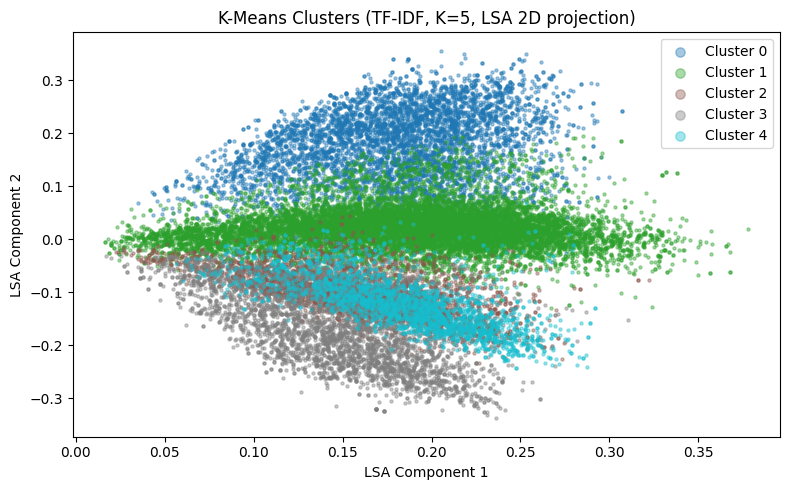

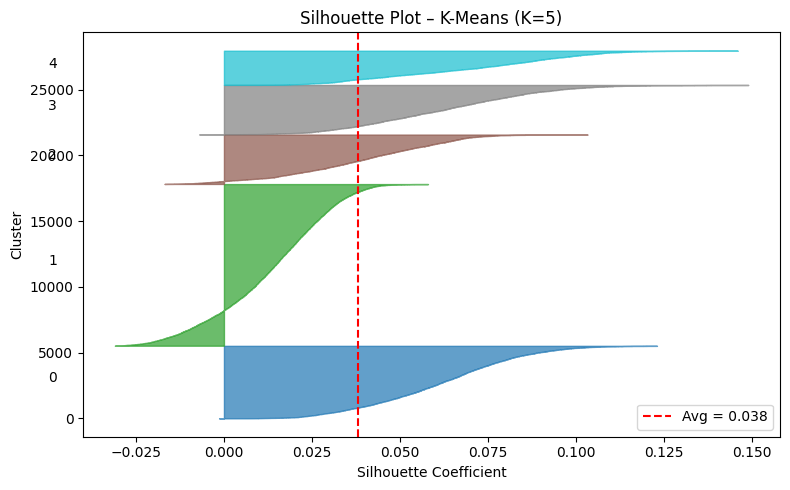

In [5]:
# ============================================================
# 5. K-Means Clustering  (K=5, seed=42)
# ============================================================
print("\n" + "="*55)
print(" K-MEANS CLUSTERING  (K=5)")
print("="*55)

kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10, max_iter=300)
km_labels = kmeans.fit_predict(X_tfidf)
df["km_cluster"] = km_labels

km_silhouette = silhouette_score(X_tfidf, km_labels, metric="cosine")
print(f"Silhouette Score (cosine): {km_silhouette:.4f}")

# Cluster size distribution
km_counts = Counter(km_labels)
print("\nCluster sizes:")
for c in sorted(km_counts):
    print(f"  Cluster {c}: {km_counts[c]} tickets")

# Top terms per K-Means cluster
print("\nTop 10 terms per K-Means cluster:")
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
for i in range(K):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"  Cluster {i}: {', '.join(top_terms)}")

# ── K-Means scatter plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colours = cm.tab10(np.linspace(0, 1, K))
for c in range(K):
    mask = km_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=5, alpha=0.4, color=colours[c], label=f"Cluster {c}")
ax.set_title("K-Means Clusters (TF-IDF, K=5, LSA 2D projection)")
ax.set_xlabel("LSA Component 1")
ax.set_ylabel("LSA Component 2")
ax.legend(markerscale=3, loc="best")
plt.tight_layout()
plt.show()

# ── Silhouette plot for K-Means ───────────────────────────
sample_sil = silhouette_samples(X_tfidf, km_labels, metric="cosine")
fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for c in range(K):
    c_sil = np.sort(sample_sil[km_labels == c])
    size_c = c_sil.shape[0]
    y_upper = y_lower + size_c
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     alpha=0.7, color=colours[c])
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10
ax.axvline(x=km_silhouette, color="red", linestyle="--",
           label=f"Avg = {km_silhouette:.3f}")
ax.set_title("Silhouette Plot – K-Means (K=5)")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
plt.show()



 HAC CLUSTERING  (K=5, Ward linkage)
Silhouette Score (euclidean on LSA-50): 0.1055

Cluster sizes:
  Cluster 0: 6921 tickets
  Cluster 1: 3587 tickets
  Cluster 2: 12208 tickets
  Cluster 3: 2892 tickets
  Cluster 4: 2311 tickets

Top 10 terms per HAC cluster:
  Cluster 0: integration, detail, project, management, provide, project management, investment, integrate, tool, saas
  Cluster 1: brand, digital, strategy, market, growth, brand growth, digital strategy, engagement, campaign, target
  Cluster 2: issue, problem, restart, resolve, update, software, data, server, recent, investment
  Cluster 3: security, breach, access, medical, unauthorized, data, unauthorized access, outdated, medical data, data breach
  Cluster 4: medical, medical data, security, data, secure, secure medical, information, hospital, sensitive, measure


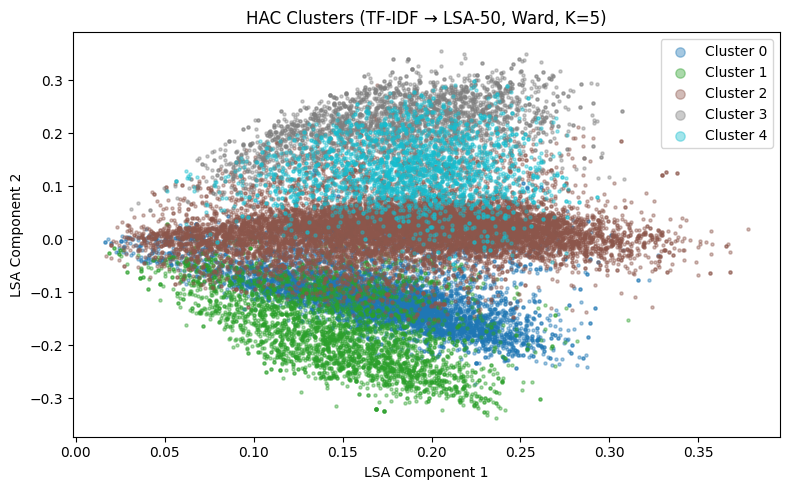


Building dendrogram (sample of 300 tickets)...


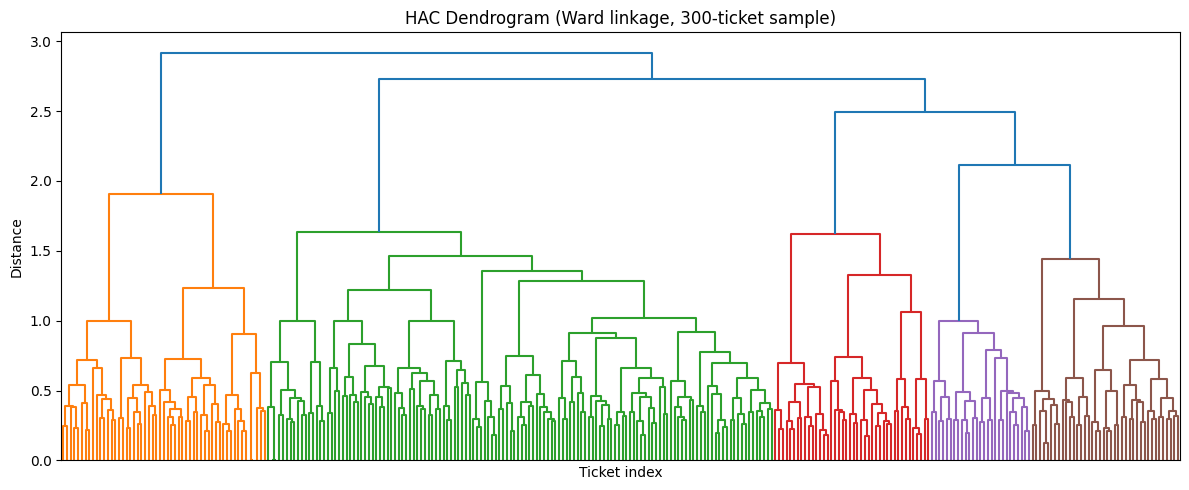

In [6]:
# ============================================================
# 6. HAC Clustering  (K=5, Ward linkage)
# ============================================================
print("\n" + "="*55)
print(" HAC CLUSTERING  (K=5, Ward linkage)")
print("="*55)

# HAC requires dense input – use LSA-reduced matrix (50 components)
svd50 = TruncatedSVD(n_components=50, random_state=SEED)
X_lsa50 = svd50.fit_transform(X_tfidf)

hac = AgglomerativeClustering(n_clusters=K, linkage="ward")
hac_labels = hac.fit_predict(X_lsa50)
df["hac_cluster"] = hac_labels

hac_silhouette = silhouette_score(X_lsa50, hac_labels, metric="euclidean")
print(f"Silhouette Score (euclidean on LSA-50): {hac_silhouette:.4f}")

# Cluster size distribution
hac_counts = Counter(hac_labels)
print("\nCluster sizes:")
for c in sorted(hac_counts):
    print(f"  Cluster {c}: {hac_counts[c]} tickets")

# Top terms per HAC cluster (via per-cluster mean TF-IDF)
print("\nTop 10 terms per HAC cluster:")
X_dense = X_tfidf.toarray()
for c in range(K):
    mask = hac_labels == c
    centroid = X_dense[mask].mean(axis=0)
    top_idx  = centroid.argsort()[::-1][:10]
    top_terms = [terms[i] for i in top_idx]
    print(f"  Cluster {c}: {', '.join(top_terms)}")

# ── HAC scatter plot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for c in range(K):
    mask = hac_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=5, alpha=0.4, color=colours[c], label=f"Cluster {c}")
ax.set_title("HAC Clusters (TF-IDF → LSA-50, Ward, K=5)")
ax.set_xlabel("LSA Component 1")
ax.set_ylabel("LSA Component 2")
ax.legend(markerscale=3, loc="best")
plt.tight_layout()
plt.show()

# ── Dendrogram (sampled for readability) ─────────────────
print("\nBuilding dendrogram (sample of 300 tickets)...")
sample_idx = np.random.RandomState(SEED).choice(len(X_lsa50), 300, replace=False)
Z = linkage(X_lsa50[sample_idx], method="ward")
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7*max(Z[:, 2]))
ax.set_title("HAC Dendrogram (Ward linkage, 300-ticket sample)")
ax.set_xlabel("Ticket index")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 7. Alignment with Ground-Truth Labels  (type column)
# ============================================================
print("\n" + "="*55)
print(" ALIGNMENT WITH GROUND-TRUTH  (type column)")
print("="*55)

true_labels = pd.Categorical(df["type"]).codes   # encode string labels → int

km_ari  = adjusted_rand_score(true_labels, km_labels)
km_nmi  = normalized_mutual_info_score(true_labels, km_labels)
hac_ari = adjusted_rand_score(true_labels, hac_labels)
hac_nmi = normalized_mutual_info_score(true_labels, hac_labels)

print(f"\n{'Method':<12} {'ARI':>8} {'NMI':>8} {'Silhouette':>12}")
print("-" * 44)
print(f"{'K-Means':<12} {km_ari:>8.4f} {km_nmi:>8.4f} {km_silhouette:>12.4f}")
print(f"{'HAC':<12} {hac_ari:>8.4f} {hac_nmi:>8.4f} {hac_silhouette:>12.4f}")

# Cross-tabulation: cluster vs ticket type
print("\nK-Means cluster × ticket type:")
print(pd.crosstab(df["km_cluster"], df["type"]))
print("\nHAC cluster × ticket type:")
print(pd.crosstab(df["hac_cluster"], df["type"]))


 ALIGNMENT WITH GROUND-TRUTH  (type column)

Method            ARI      NMI   Silhouette
--------------------------------------------
K-Means        0.2553   0.2583       0.0381
HAC            0.2722   0.2925       0.1055

K-Means cluster × ticket type:
type        Change  Incident  Problem  Request
km_cluster                                    
0              657      2048     1021     1788
1              259      7943     4033       57
2              743        67       52     2892
3              656       872      638     1597
4              649       163       88     1696

HAC cluster × ticket type:
type         Change  Incident  Problem  Request
hac_cluster                                    
0              1470       517      454     4480
1               604       858      590     1535
2               288      7787     3830      303
3                17      1923      948        4
4               585         8       10     1708


In [8]:
# ============================================================
# 8. Coherence Calculation
# ============================================================


def calculate_coherence(texts, labels, n_clusters):
    """
    Calculate coherence score for clustering using top words per cluster.
    """
    tokenized_texts = [text.split() for text in texts]
    dictionary = Dictionary(tokenized_texts)
    
    cluster_topics = []
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_texts = [tokenized_texts[i] for i, mask in enumerate(cluster_mask) if mask]
        
        word_freq = Counter()
        for text in cluster_texts:
            word_freq.update(text)
        
        top_words = [word for word, count in word_freq.most_common(10)]
        cluster_topics.append(top_words)
    
    cm = CoherenceModel(
        topics=cluster_topics,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    return cm.get_coherence()

print("\n" + "="*70)
print("COHERENCE CALCULATION")
print("="*70)

# Calculate coherence for K-Means
km_coherence = calculate_coherence(
    df['trunc_processed_text'].tolist(),
    km_labels,
    K
)
print(f"K-Means Coherence: {km_coherence:.4f}")

# Calculate coherence for HAC
hac_coherence = calculate_coherence(
    df['trunc_processed_text'].tolist(),
    hac_labels,
    K
)
print(f"HAC Coherence: {hac_coherence:.4f}")


COHERENCE CALCULATION
K-Means Coherence: 0.7605
HAC Coherence: 0.7280


In [9]:
# ============================================================
# 9. Final Summary
# ============================================================

print("\n" + "="*70)
print("TF-IDF Clustering Analysis Complete")
print("="*70)

print("\nConfiguration:")
print(f"  Method: TF-IDF")
print(f"  Features: {X_tfidf.shape[1]}")
print(f"  N-grams: (1, 2)")
print(f"  k: {K}")
print(f"  seed: {SEED}")
print(f"  Documents: {len(df):,}")

print("\nK-Means Results:")
print(f"  Silhouette: {km_silhouette:.4f}")
print(f"  ARI: {km_ari:.4f}")
print(f"  NMI: {km_nmi:.4f}")
print(f"  Coherence: {km_coherence:.4f}")
print(f"  Inertia: {kmeans.inertia_:.2f}")

print("\nHAC Results:")
print(f"  Silhouette: {hac_silhouette:.4f}")
print(f"  ARI: {hac_ari:.4f}")
print(f"  NMI: {hac_nmi:.4f}")
print(f"  Coherence: {hac_coherence:.4f}")

print("\n" + "="*70)

# Create results summary DataFrame
results_summary = pd.DataFrame({
    'Method': ['K-Means', 'HAC'],
    'Silhouette': [km_silhouette, hac_silhouette],
    'ARI': [km_ari, hac_ari],
    'NMI': [km_nmi, hac_nmi],
    'Coherence': [km_coherence, hac_coherence],
    'k': [K, K],
    'seed': [SEED, '-']
})

print("\nResults Summary:")
print(results_summary.to_string(index=False))






TF-IDF Clustering Analysis Complete

Configuration:
  Method: TF-IDF
  Features: 5000
  N-grams: (1, 2)
  k: 5
  seed: 42
  Documents: 27,919

K-Means Results:
  Silhouette: 0.0381
  ARI: 0.2553
  NMI: 0.2583
  Coherence: 0.7605
  Inertia: 25954.32

HAC Results:
  Silhouette: 0.1055
  ARI: 0.2722
  NMI: 0.2925
  Coherence: 0.7280


Results Summary:
 Method  Silhouette      ARI      NMI  Coherence  k seed
K-Means    0.038113 0.255345 0.258264   0.760451  5   42
    HAC    0.105528 0.272210 0.292483   0.727978  5    -
